<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/OB/week06_%ED%95%A9%EC%84%B1%EA%B3%B1%EC%8B%A0%EA%B2%BD%EB%A7%9D1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5.1 합성곱신경망

 역전파를 복습하자면 순전파 과정에 따라 계산된 오차 정보가 신경망
의 모든 노드(출력층→은닉층→입력층)로 전송됩니다. 이러한 계산 과정은 복잡하고 많은 자원
(CPU 혹은 GPU, 메모리)을 요구합니다. 또한， 계산하는 데도 오래 걸립니다. 이 문제를 해결하
고자 하는 것이 합성곱 신경망입니다. 합성곱 신경망은 이미지 전체를 한 번에 계산하는 것이 아
닌 이미지의 국소적 부분을 계산함으로써 시간과 자원을 절약하여 이미지의 세밀한 부분까지 분
석할수있는신경망입니다.

#5.1.1 합성곱층의 필요성

이미지 분석은 다음 그림의 왼쪽과 같은 3X3 배열을 오른쪽과 같이 펼쳐서(fJattening) 각 픽셀에
가중치를 곱하여 은닉층으로 전달하게 됩니다. 하지만 그림에서 보이는 것처럼 이미지를 펼쳐서
분석하면 데이터의 공간적 구조를 무시하게 되는데， 이것을 방지하려고 도입된 것이 합성곱층입
니다.

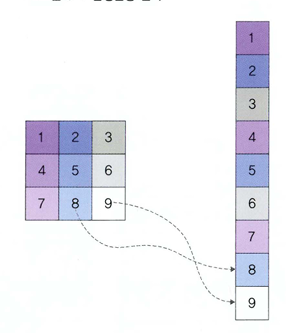

# 5.1.2 합성곱 신경망 구조

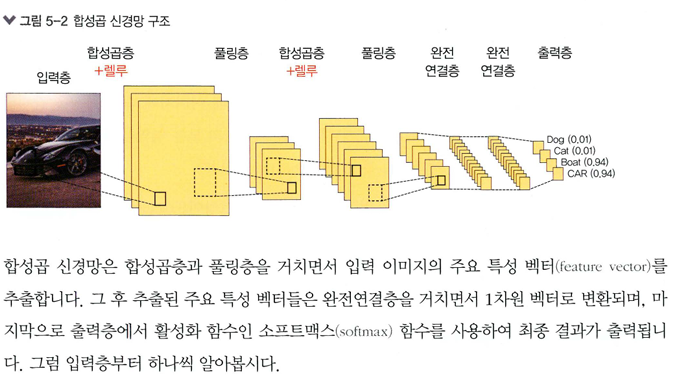

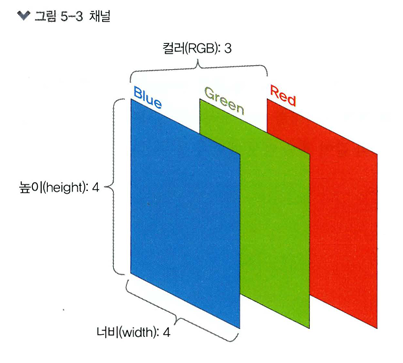

1. 입력층
입력 이미지 데이터가 최초로 거치게 되는 계층

(높이,너비,채널)값을 갖는 3차원 데이터
이때 채널은 흑백이면 1 컬러면 3


2. 합성곱층
 입력 데이터에서 특성을 추출하는 역할
 입력 이미지가 들어왔을 때 이미지에 대한 특성을 감지하
기 위해 커널(kerneJ)이나 필터를 사용합니다. 커널/필터는 이미지의 모든 영역을 훌으면서 특성을
추출하게 되는데， 이렇게 추출된 결과물이 특성 맵(fearure map)입니다.  


이때 커널은 3X3, 5x 5 크기로 적용되는 것이 일반적이며， 스트라이드(stride) 1라는 지정된 간격
에 따라 순차적으로 이동합니다.
다음은스트라이드가1일 때 이동하는과정

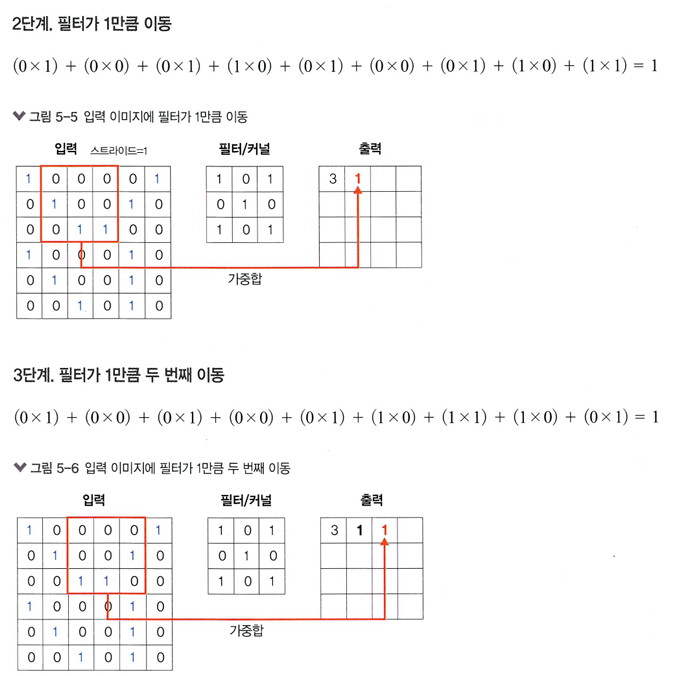


 컬러 이미지의 합성곱:

 특징:  필터 채널이 3이라는 것과 둘째， RGB
각각에 서로 다른 기중치로 합성곱을 적용한 후 결과를 더해 준다는 것( 이때 필터 채널이 3이라고 해서 필터 개수도 세 개라고 오해하기
쉬운데， 실제로는 필터 개수가 한 개라는 점에 주의)

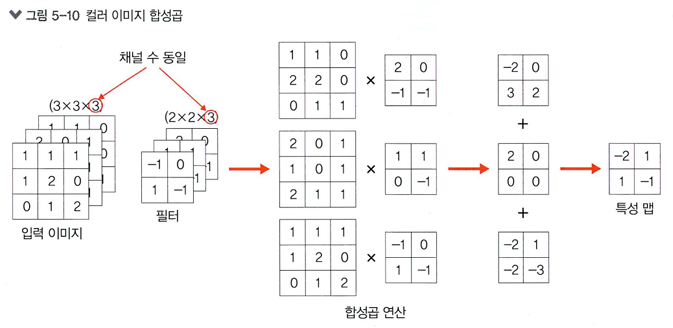

 필터가 두 개 이상인 합성곱

 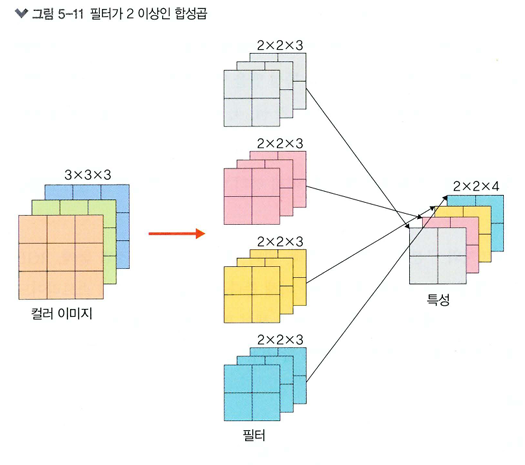

 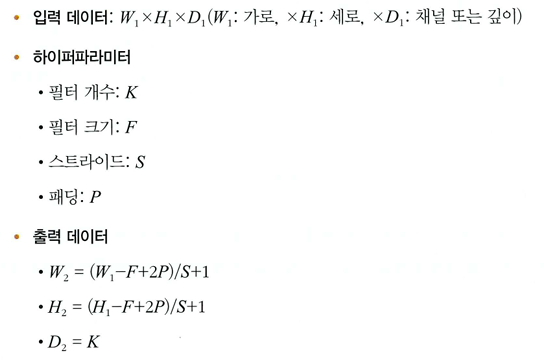

3. 풀링층

 합성곱층과 유사하게 특성 뱀의 차원을 다운 샘플링하여 연산량을 감소시
키고， 주요한 특성 벡터를 추출하여 학습을 효과적으로 할 수 있게 합니다.

풀링 연산에는 두 가지가 시용됩니다.

• 최대 풀링(max pooling): 대상 영역에서 최뱃값을추출   
• 평균풀링(average pooling): 대상 영역에서 평균을반환

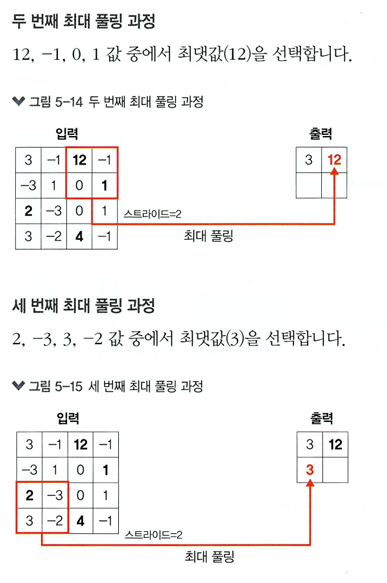

평균 풀링의 계산 과정은 최대 풀링과 유사한 방식으로 진행하되 다음과 같이 각 필터의 평균으로
계산

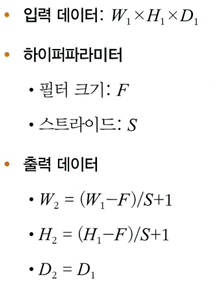

4. 완전 연결층

 3차원 벡터에서 1차원 벡터로 펼쳐짐

 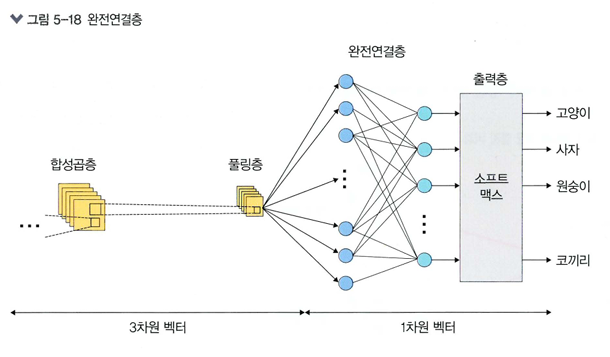

5. 출력층  
 소프트맥스 활성화 함수가 사용되는데， 입력받은 값을 0~1 사이의 값
으로 출력합니다. 따라서 마지막 출력층의 소프트맥스 함수를 사용하여 이미지가 각 레이블(label)
에 속할 확률 값이 출력되며 이때 가장 높은 확률 값을 갖는 레이블이 최종 값으로 선정


## 5.1.3  1D, 2D, 3D 합성곱
합성곱은 이동하는 방향의 수와 출력 형태에 따라 분류

1. 1D 합성곱  
 필터가 시간을 축으로 좌우로만 이동할 수 있는 합성곱/ 다음 그림과 같이 출력 형태는 1D의 배열/그래프 곡선을완화할때 많이 사용
 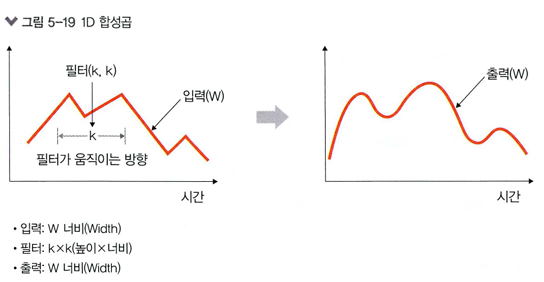


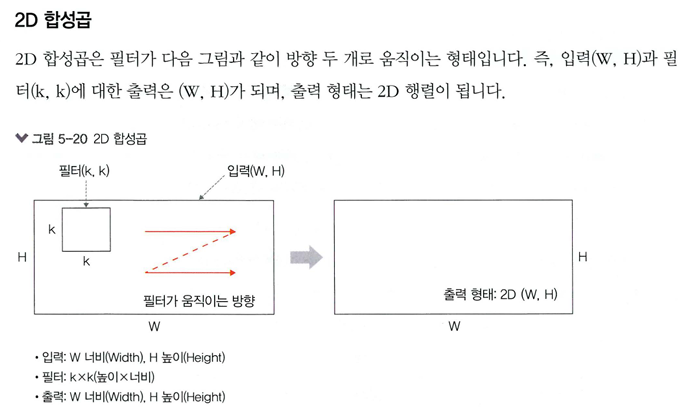

3D 합성곱
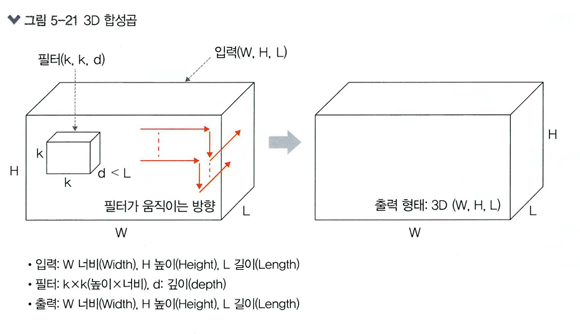


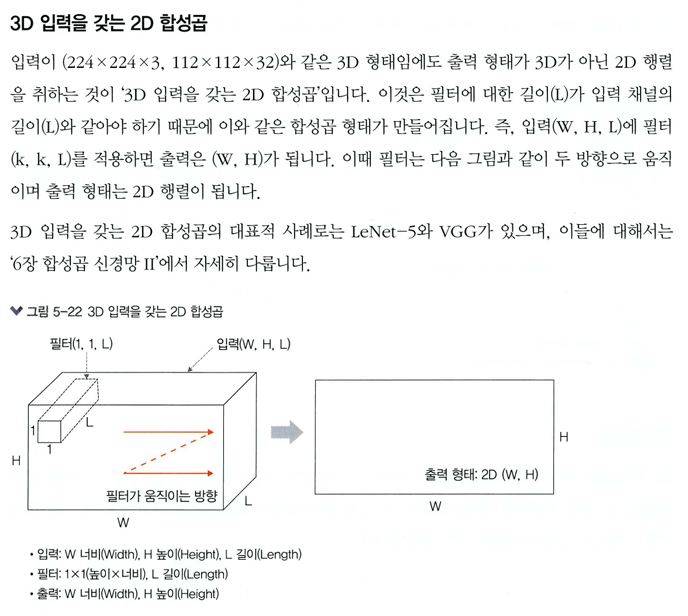

1 x1 합성곱

입력(w， H, L)에 필터(1， 1, L)를 적용

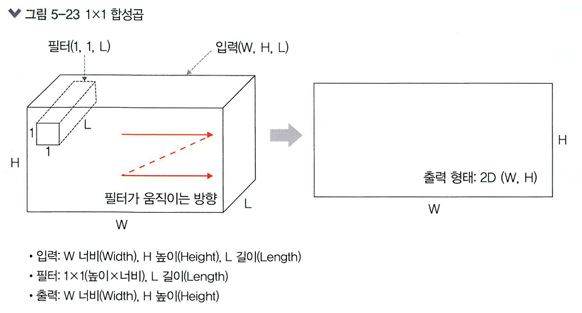